In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.spatial.distance import cdist
from scipy.stats import spearmanr
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

In [65]:
def cw_silhouette_score(X, labels, epsilon=1e-8):
    X = np.asarray(X)
    labels = np.asarray(labels)
    n = len(X)
    unique_labels = np.unique(labels)

    D = cdist(X, X)
    centroids = {l: X[labels == l].mean(axis=0) for l in unique_labels}

    dist_to_centroid = np.zeros(n)
    for i in range(n):
        d = np.linalg.norm(X[i] - centroids[labels[i]])
        dist_to_centroid[i] = d + epsilon

    silhouette_scores = np.zeros(n)
    for i in range(n):
        same_cluster = (labels == labels[i])
        same_cluster[i] = False
        if not np.any(same_cluster):
            silhouette_scores[i] = 0
            continue

        intra_dist = D[i, same_cluster]
        intra_weights = 1.0 / dist_to_centroid[same_cluster]
        a = np.sum(intra_dist * intra_weights) / np.sum(intra_weights)

        b = np.inf
        for l in unique_labels:
            if l == labels[i]:
                continue
            mask = (labels == l)
            inter_dist = D[i, mask]
            b_l = np.sum(inter_dist) / len(inter_dist)
            b = min(b, b_l)

        silhouette_scores[i] = (b - a) / max(a, b)

    return silhouette_scores.mean()


# Experiment

In [66]:
#loading datasets
def make_gaussian(sigma, n_per_cluster=67, seed=51):
    rng = np.random.default_rng(seed)

    centroids = np.array([
        [5.0, 3.0], 
        [7.0, 7.0], 
        [3.0, 7.0]
    ])
    
    X = np.vstack([
        rng.normal(loc=c, scale=sigma, size=(n_per_cluster, 2))
        for c in centroids
    ])

    y = np.repeat([0, 1, 2], n_per_cluster)
    
    return X, y


def load_seeds(path="seeds_dataset.tsv"):
    cols = ['area','perimeter','compactness','kernel_length',
            'kernel_width','asymmetry','groove_length','target']
    df = pd.read_csv(path, sep='\t', header=None, names=cols)
    X = df.drop('target', axis=1).values
    y = df['target'].values - 1    
    return X, y


def load_wine_data():
    wine = load_wine()
    X = wine.data
    y = wine.target
    return X, y

In [67]:
def run_epsilon_experiment(X, y, true_k, eps_values, k_range=range(2, 7),
                            n_runs=5, scale=True, name=""):
    
    if scale:
        X = StandardScaler().fit_transform(X)

    records = []
    for eps in eps_values:
        scores_at_true_k = []
        selected_ks = []
        spearmans = []

        for run in range(n_runs):
            cw_scores = []
            ari_scores = []

            for k in k_range:
                km = KMeans(n_clusters=k, random_state=run, n_init=10)
                pred = km.fit_predict(X)

                cw = cw_silhouette_score(X, pred, epsilon=eps)
                ari = adjusted_rand_score(y, pred)

                cw_scores.append(cw)
                ari_scores.append(ari)

            # Score at true k
            true_k_idx = list(k_range).index(true_k)
            scores_at_true_k.append(cw_scores[true_k_idx])

            # Selected k
            selected_ks.append(list(k_range)[np.argmax(cw_scores)])

            # Spearman corr
            rho, _ = spearmanr(cw_scores, ari_scores)
            spearmans.append(rho)

        records.append({
            'dataset': name,
            'epsilon': eps,
            'cw_score_mean': np.mean(scores_at_true_k),
            'cw_score_std': np.std(scores_at_true_k),
            'selected_k_mode': pd.Series(selected_ks).mode()[0],
            'selected_k_mean': np.mean(selected_ks),
            'spearman_mean': np.mean(spearmans),
            'spearman_std': np.std(spearmans),
            'pct_correct_k': np.mean([k == true_k for k in selected_ks]) * 100,
        })

    return pd.DataFrame(records)


In [68]:
#running all expts
eps_values = [1e-1, 1e-2, 1e-3, 1e-4, 1e-6, 1e-8, 1e-10]
log_eps = np.log10(eps_values)
true_k = 3
k_range = range(2, 7)

# Gaussian
all_results = []
for sigma, label in [(0.5, 'Gaussian σ=0.5'), (1.0, 'Gaussian σ=1.0'), (1.5, 'Gaussian σ=1.5')]:
    X, y = make_gaussian(sigma)
    df = run_epsilon_experiment(X, y, true_k=true_k, eps_values=eps_values,
                                 k_range=k_range, n_runs=10, scale=False, name=label)
    all_results.append(df)

# Seeds
X_seeds, y_seeds = load_seeds(r"datasets\seeds\seeds_dataset.tsv")
df_seeds = run_epsilon_experiment(X_seeds, y_seeds, true_k=true_k, eps_values=eps_values,
                                   k_range=k_range, n_runs=10, scale=True, name='Seeds')
all_results.append(df_seeds)

#Wine
X_wine, y_wine = load_wine_data()
df_wine = run_epsilon_experiment(X_wine, y_wine, true_k=true_k, eps_values=eps_values,
                                  k_range=k_range, n_runs=10, scale=True, name='Wine')
all_results.append(df_wine)

results = pd.concat(all_results, ignore_index=True)


In [69]:
# print summary table
print(f"{'Dataset':<22} {'ε':<10} {'CW-Sil (true k)':<20} {'Selected k':<12} {'% Correct k':<14} {'Spearman ρ'}")
print("=" * 90)
for _, row in results.iterrows():
    print(f"{row['dataset']:<22} {row['epsilon']:<10.0e} "
          f"{row['cw_score_mean']:>6.4f} ± {row['cw_score_std']:.4f}   "
          f"{row['selected_k_mode']:<18.0f} "
          f"{row['pct_correct_k']:<14.1f} "
          f"{row['spearman_mean']:.4f} ± {row['spearman_std']:.4f}")



Dataset                ε          CW-Sil (true k)      Selected k   % Correct k    Spearman ρ
Gaussian σ=0.5         1e-01      0.7926 ± 0.0000   3                  100.0          0.7200 ± 0.0600
Gaussian σ=0.5         1e-02      0.7990 ± 0.0000   3                  100.0          0.7200 ± 0.0600
Gaussian σ=0.5         1e-03      0.8001 ± 0.0000   3                  100.0          0.7200 ± 0.0600
Gaussian σ=0.5         1e-04      0.8002 ± 0.0000   3                  100.0          0.7200 ± 0.0600
Gaussian σ=0.5         1e-06      0.8002 ± 0.0000   3                  100.0          0.7200 ± 0.0600
Gaussian σ=0.5         1e-08      0.8002 ± 0.0000   3                  100.0          0.7200 ± 0.0600
Gaussian σ=0.5         1e-10      0.8002 ± 0.0000   3                  100.0          0.7200 ± 0.0600
Gaussian σ=1.0         1e-01      0.5985 ± 0.0000   3                  100.0          0.6500 ± 0.0500
Gaussian σ=1.0         1e-02      0.6075 ± 0.0000   3                  100.0          0.73

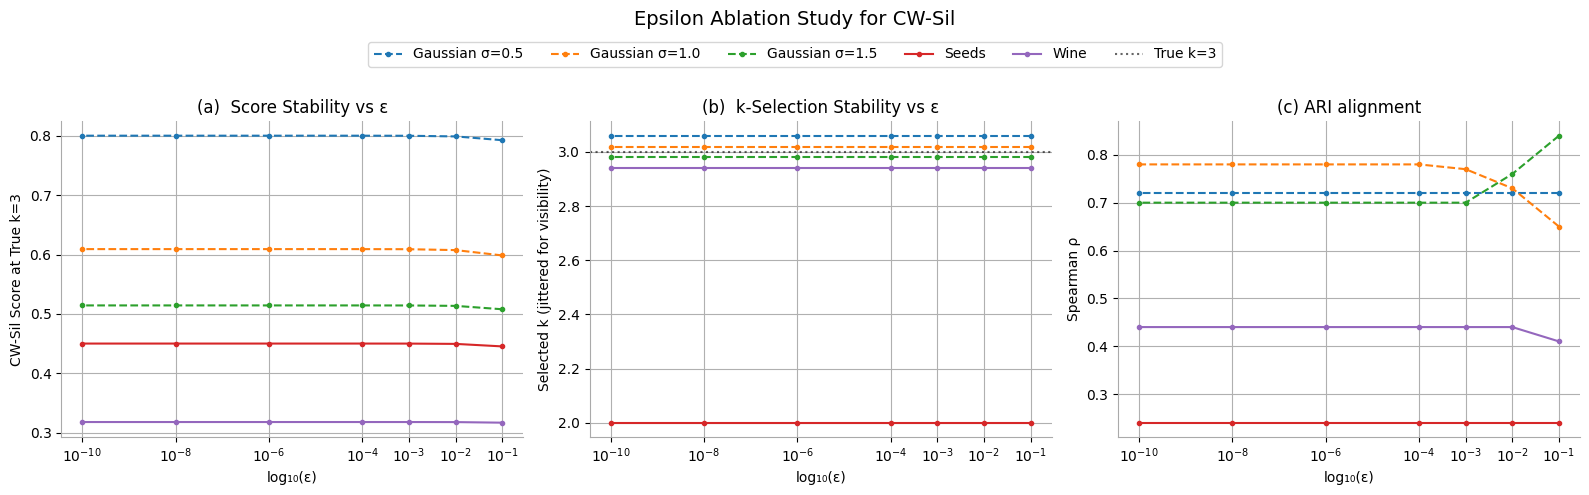

In [71]:
LINE_STYLES = {
    'Gaussian σ=0.5': '--',
    'Gaussian σ=1.0': '--',
    'Gaussian σ=1.5': '--',
    'Seeds':          '-',
    'Wine':           '-',
}

datasets_order = ['Gaussian σ=0.5', 'Gaussian σ=1.0', 'Gaussian σ=1.5', 'Seeds', 'Wine']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

fig.suptitle("Epsilon Ablation Study for CW-Sil", fontsize=14)

for ax in axes:
    ax.set_facecolor('white')
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#AAAAAA')

# Subplot 1: CW-Sil score at true k 
ax1 = axes[0]

for ds in datasets_order:
    sub = results[results['dataset'] == ds]
    x = np.log10(sub['epsilon'].values)
    
    ax1.plot(x, sub['cw_score_mean'].values, marker=".", linestyle=LINE_STYLES[ds], label=ds)
    
    ax1.fill_between(x, sub['cw_score_mean'] - sub['cw_score_std'], sub['cw_score_mean'] + sub['cw_score_std'], alpha=0.15)

ax1.set_xlabel('log₁₀(ε)')
ax1.set_ylabel('CW-Sil Score at True k=3')
ax1.set_title('(a)  Score Stability vs ε')
ax1.grid()

ax1.set_xticks(np.log10(eps_values))
ax1.set_xticklabels([f'10$^{{{int(np.log10(e))}}}$' for e in eps_values])


# Subplot 2: Selected k 
ax2 = axes[1]

# Small vertical jitter so datasets stacked at same k are all visible
jitter = {
    'Gaussian σ=0.5': +0.06,
    'Gaussian σ=1.0': +0.02,
    'Gaussian σ=1.5': -0.02,
    'Seeds':           0.00,
    'Wine':           -0.06,
}

for ds in datasets_order:
    sub = results[results['dataset'] == ds]
    x = np.log10(sub['epsilon'].values)
    y_vals = sub['selected_k_mean'].values + jitter[ds]
    
    ax2.plot(x, y_vals, marker=".", linestyle=LINE_STYLES[ds], label=ds)

ax2.axhline(y=true_k, color='black', linestyle=':', linewidth=1.5, alpha=0.6, label='True k=3')

ax2.set_xlabel('log₁₀(ε)')
ax2.set_ylabel('Selected k (jittered for visibility)')
ax2.set_title('(b)  k-Selection Stability vs ε')
ax2.grid()

ax2.set_xticks(np.log10(eps_values))
ax2.set_xticklabels([f'10$^{{{int(np.log10(e))}}}$' for e in eps_values])


# Subplot 3: Spearman correlation
ax3 = axes[2]

for ds in datasets_order:
    sub = results[results['dataset'] == ds]
    x = np.log10(sub['epsilon'].values)

    ax3.plot(x, sub['spearman_mean'].values, marker=".", linestyle=LINE_STYLES[ds])

ax3.set_xlabel('log₁₀(ε)')
ax3.set_ylabel('Spearman ρ')
ax3.set_title('(c) ARI alignment')
ax3.grid()

ax3.set_xticks(np.log10(eps_values))
ax3.set_xticklabels([f'$10^{{{int(np.log10(e))}}}$' for e in eps_values])


# ONE shared legend
handles, labels = ax2.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(labels), bbox_to_anchor=(0.5, 0.93))

plt.tight_layout(rect=[0,0,1,0.9])
plt.show()